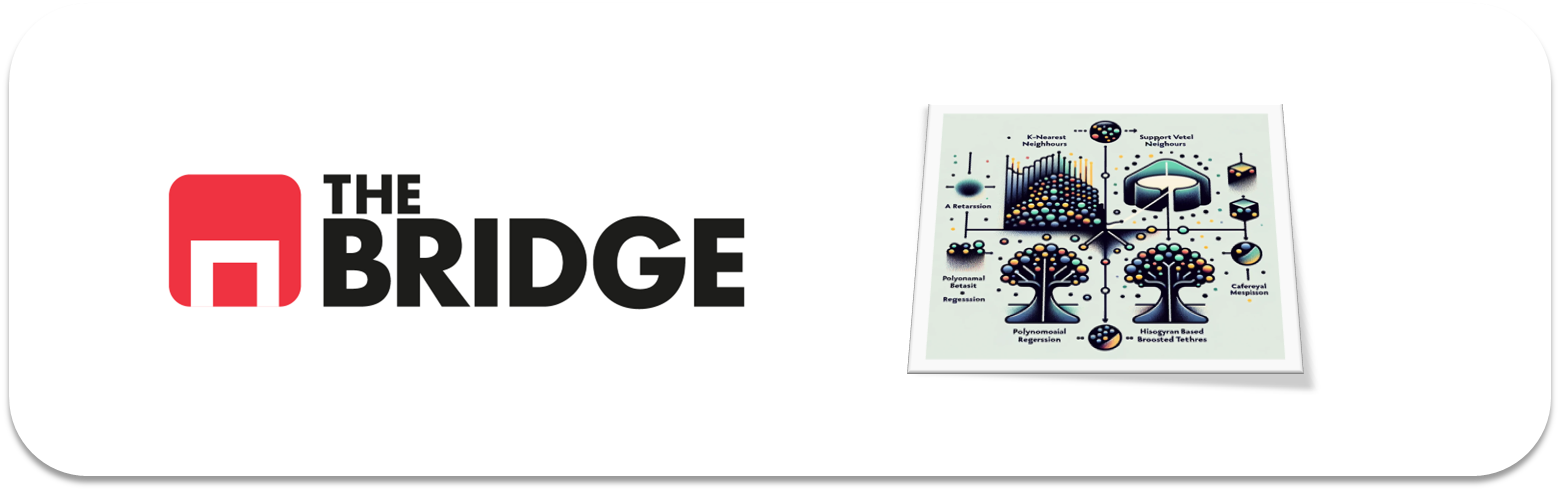

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("./data/wines_dataset.csv", sep = "|")

In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,7.7,0.39,0.34,10.00,0.056,35.0,178.0,0.99740,3.26,0.60,10.2,5,white
6493,8.2,0.73,0.21,1.70,0.074,5.0,13.0,0.99680,3.20,0.52,9.5,5,red
6494,7.4,0.31,0.48,14.20,0.042,62.0,204.0,0.99830,3.06,0.59,9.4,5,white
6495,8.3,0.65,0.10,2.90,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5,red


### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [4]:
target_clas = "quality"
target_reg = "alcohol"

In [5]:
df["quality"].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

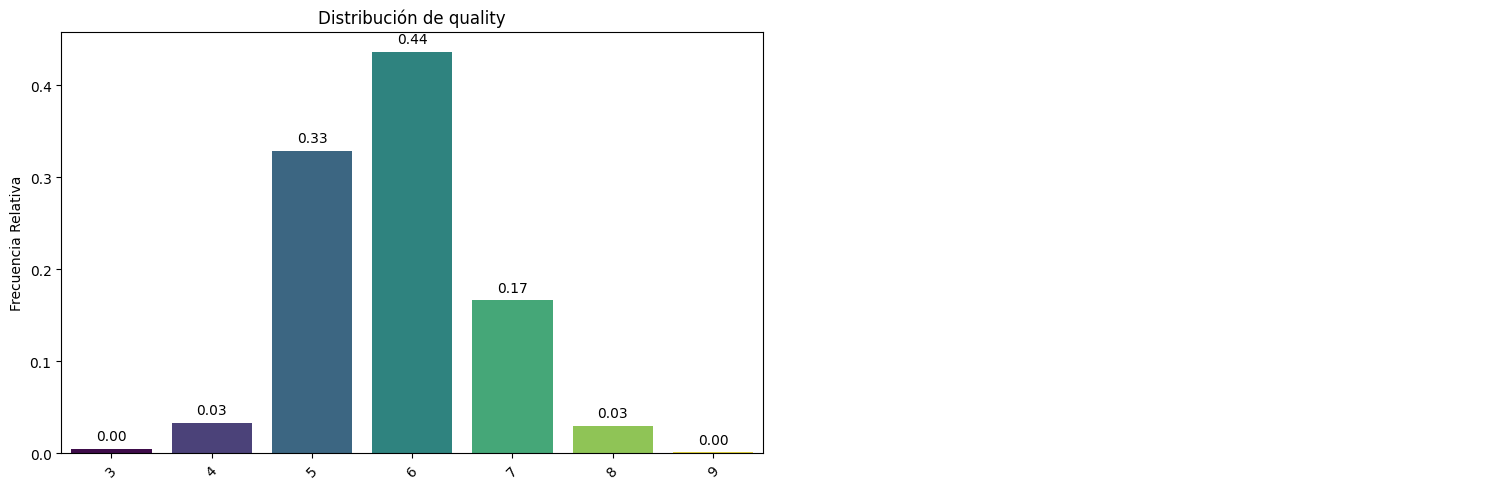

'\nClaramente podemos ver la distribución de la target de clasificación en el siguiente gràfico. Podemos observar, en primer lugar, el irregular peso de \nlas clases. En cierto modo, recuerda a una campana de gauss por lo que no sera necesario aplicar el logaritmo a la variable para que el modelo se comporte\nde manera adecuada, siempre y cuando tengamos en mente los pesos.\n'

In [6]:
bt.pinta_distribucion_categoricas(df, [target_clas], mostrar_valores= True, relativa= True)

'''
Claramente podemos ver la distribución de la target de clasificación en el siguiente gràfico. Podemos observar, en primer lugar, el irregular peso de 
las clases. En cierto modo, recuerda a una campana de gauss por lo que no sera necesario aplicar el logaritmo a la variable para que el modelo se comporte
de manera adecuada, siempre y cuando tengamos en mente los pesos.
'''

'\nEn este caso, la situación es más peculiar, como suele ocurrir en los targets de regresión lineal, podemos observar que el conteo de la cantidad de grado en \nalcohol no es regular en todos los casos, de hecho, vemos alrededor del 10.1 o 10.2 como el conteo se desploma\n'

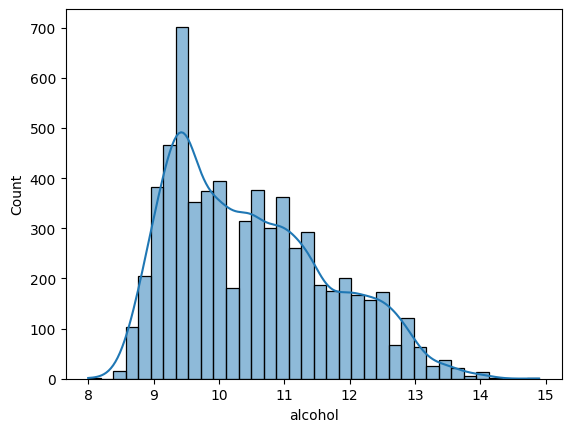

In [7]:
sns.histplot(data= df, x= target_reg, kde= True)

'''
En este caso, la situación es más peculiar, como suele ocurrir en los targets de regresión lineal, podemos observar que el conteo de la cantidad de grado en 
alcohol no es regular en todos los casos, de hecho, vemos alrededor del 10.1 o 10.2 como el conteo se desploma
'''

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [8]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,7.7,0.39,0.34,10.00,0.056,35.0,178.0,0.99740,3.26,0.60,10.2,5,white
6493,8.2,0.73,0.21,1.70,0.074,5.0,13.0,0.99680,3.20,0.52,9.5,5,red
6494,7.4,0.31,0.48,14.20,0.042,62.0,204.0,0.99830,3.06,0.59,9.4,5,white
6495,8.3,0.65,0.10,2.90,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5,red


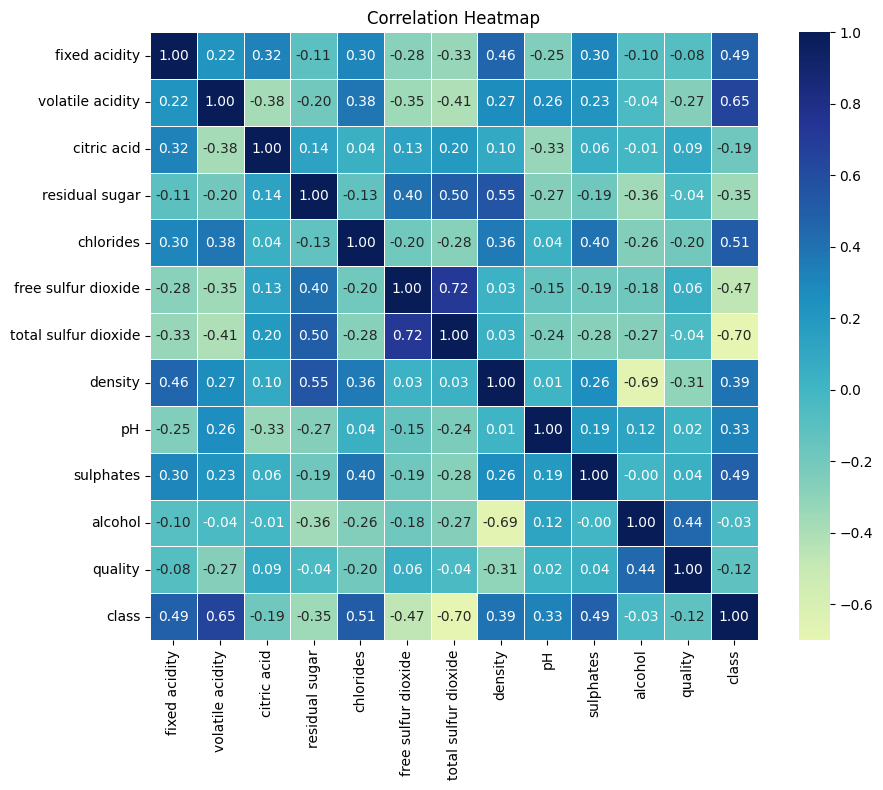

'\nNinguna me hace especial gracia para sacar una correlación directa, como no me convence de\nesta forma, hare un randomforestclassifier, pero solamente para hacer uso de su función \nfeature_importance\n'

In [9]:
'''
A priori, el enunciado me hace pensar que, el modelo se basara en las 
features que hagan incapie en composiciones quimicas, lo podemos comprobar
con un heatmap, donde lo pongamos a prueba entre ellas y la target 
'''
mapeo_cut = {
    "white": 1,
    "red": 2
}
df["class"] = df["class"].map(mapeo_cut)
correlation = df.corr()



plt.figure(figsize=(10, 8))
sns.heatmap(correlation, 
            annot=True,      # Show correlation valuesx
            cmap='YlGnBu',  
            center=0,        
            fmt='.2f',       
            square=True,      
            linewidths=0.5)   

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

'''
Ninguna me hace especial gracia para sacar una correlación directa, como no me convence de
esta forma, hare un randomforestclassifier, pero solamente para hacer uso de su función 
feature_importance
'''

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42)

In [11]:
X_train = train_set.drop(target_clas, axis = 1)
y_train = train_set[target_clas]

X_test = test_set.drop(target_clas, axis = 1)
y_test = test_set[target_clas]

In [12]:
from sklearn.ensemble import RandomForestClassifier
base_clf = RandomForestClassifier(max_depth = 10, random_state= 42, class_weight= "balanced")
base_clf.fit(X_train, y_train) # Para el feature Importance

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [13]:
display(pd.DataFrame({"features": base_clf.feature_names_in_, "importance": base_clf.feature_importances_}).sort_values("importance",ascending = False))

'''
No es que tenga los mejores valores para la feature importance, pero ahora sabemos cuales
son las features que hacen referencia a valores quimicos, ordenados de mas a menos importantes
Entenderemos que son:
- Alcohol
- Volatile Acidity
- Chlorides 
- Total sulfur dioxide

Ahora que hemos probado estos casos, vamos con los modelos, para esta ocasión, usaremos RandomForest, XGBClassifier y LGBMClassifier
'''

,features,importance
10,alcohol,0.130879
7,density,0.116457
5,free sulfur dioxide,0.108759
4,chlorides,0.106579
6,total sulfur dioxide,0.088279
1,volatile acidity,0.084857
0,fixed acidity,0.084248
8,pH,0.078643
9,sulphates,0.069140
2,citric acid,0.064987


'\nNo es que tenga los mejores valores para la feature importance, pero ahora sabemos cuales\nson las features que hacen referencia a valores quimicos, ordenados de mas a menos importantes\nEntenderemos que son:\n- Alcohol\n- Volatile Acidity\n- Chlorides \n- Total sulfur dioxide\n\nAhora que hemos probado estos casos, vamos con los modelos, para esta ocasión, usaremos RandomForest, XGBClassifier y LGBMClassifier\n'

In [14]:
from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier 

In [15]:
cross_val_score(base_clf, X_train, y_train, cv = 5, scoring= "balanced_accuracy")

array([0.34457241, 0.34473938, 0.34693615, 0.32591897, 0.34950759])

In [16]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

print("Recall medio:", np.mean(cross_val_score(base_clf, X_train, y_train, cv = 5, scoring= "balanced_accuracy")))

Recall medio: 0.3423348994130818


In [17]:
'''

'''
print(classification_report(y_test, base_clf.predict(X_test)))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.30      0.23      0.26        43
           5       0.62      0.71      0.66       432
           6       0.65      0.48      0.55       562
           7       0.44      0.67      0.53       210
           8       0.55      0.47      0.51        47

    accuracy                           0.58      1300
   macro avg       0.43      0.43      0.42      1300
weighted avg       0.59      0.58      0.57      1300



In [18]:
recall_scores = cross_val_score(
    base_clf, X_train, y_train,
    cv=5,
    scoring='recall_macro'
)

print(f"Recall CV: {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
print(f"Scores individuales: {recall_scores}")

Recall CV: 0.3423 (+/- 0.0084)
Scores individuales: [0.34457241 0.34473938 0.34693615 0.32591897 0.34950759]


In [19]:
# Voy a probar de hacer un escalado, a ver si me da mejores resultados

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter= 5000,
                           class_weight= "balanced",
                           random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [21]:
# He probado con logistic regression una vez estandarizado, voy a hacer lo mismo con demas modelos
print(classification_report(y_train, model.predict(X_train_scaled)))

              precision    recall  f1-score   support

           3       0.02      0.46      0.04        24
           4       0.13      0.49      0.21       173
           5       0.56      0.48      0.52      1706
           6       0.60      0.24      0.35      2274
           7       0.32      0.28      0.30       869
           8       0.10      0.54      0.17       146
           9       0.05      1.00      0.10         5

    accuracy                           0.34      5197
   macro avg       0.26      0.50      0.24      5197
weighted avg       0.51      0.34      0.38      5197



In [22]:
base_clf_scaled = RandomForestClassifier(max_depth = 15, random_state= 42, class_weight="balanced")
base_clf_scaled.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [23]:
print(classification_report(y_test, base_clf_scaled.predict(X_test_scaled)))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.70      0.16      0.26        43
           5       0.71      0.74      0.72       432
           6       0.67      0.69      0.68       562
           7       0.60      0.65      0.62       210
           8       0.92      0.49      0.64        47

    accuracy                           0.67      1300
   macro avg       0.60      0.46      0.49      1300
weighted avg       0.68      0.67      0.67      1300



In [24]:
# No tiene pinta que haya overfiteado, seguir  
recall_scores = cross_val_score(
    base_clf_scaled, X_train_scaled, y_train,
    cv=5,
    scoring='recall_macro'
)

print(f"Recall CV: {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
print(f"Scores individuales: {recall_scores}")

Recall CV: 0.3394 (+/- 0.0083)
Scores individuales: [0.3535493  0.33451026 0.34436013 0.33195089 0.3327473 ]


In [25]:
xgb_clf = XGBClassifier(max_depth = 5, 
                        random_state = 42)

lgb_clf = LGBMClassifier(max_depth= 5, 
                         random_state = 42, 
                         verbose = -1,
                         n_jobs= -1)

In [26]:
from sklearn.preprocessing import LabelEncoder

# Codificar las clases UNA VEZ
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Verificar
print("Clases originales:", le.classes_)  
print("Clases codificadas:", np.unique(y_train_encoded))

Clases originales: [3 4 5 6 7 8 9]
Clases codificadas: [0 1 2 3 4 5 6]


In [27]:
X_train_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,class
0,0.530566,-0.979287,0.553261,-0.682946,-0.206188,0.413075,-0.855503,0.426887,0.692811,2.696948,0.678033,1.740311
1,-0.087744,-0.979287,2.882601,2.118572,-0.359312,0.746349,1.063516,1.622065,1.005292,0.939171,-1.248291,-0.574610
2,0.298700,1.046217,-0.542899,-0.892015,-0.481811,-1.142201,-0.204093,-0.901088,-1.057086,-1.629887,0.259267,-0.574610
3,-0.937920,-0.549635,-0.268859,0.466930,-0.083689,0.357530,0.288866,0.058374,-0.994590,-0.210144,-0.913278,-0.574610
4,1.380743,0.248291,0.621771,-0.641133,1.447549,-1.364383,-1.859027,0.440167,-0.557116,0.330710,1.180553,1.740311
...,...,...,...,...,...,...,...,...,...,...,...,...
5192,-0.628765,-0.611014,1.238361,1.282298,-0.267438,1.635078,1.679715,0.626083,-0.244634,0.263103,-0.997031,-0.574610
5193,-0.474187,-0.733772,-0.268859,1.376378,0.069435,-0.309017,0.165626,1.276791,1.442767,-0.548178,-0.913278,-0.574610
5194,-0.474187,-0.856530,0.416241,0.508744,-0.114314,-0.031289,0.517740,-0.004705,0.630314,0.195496,0.426774,-0.574610
5195,0.066834,0.432428,-0.200349,-0.766574,-0.726809,-0.253471,-0.732264,-1.933589,-1.619553,-1.224246,2.101838,-0.574610


In [28]:
for nombre, modelo in zip(["Random Forest","XGboost","LightGBM"],[base_clf, xgb_clf, lgb_clf]):
    print(f"Para {nombre}:", end = " ")
    print("Recall medio:", np.mean(cross_val_score(modelo, X_train_scaled, y_train_encoded, cv = 5, scoring = "recall_macro")))

Para Random Forest: Recall medio: 0.34315775493903145
Para XGboost: Recall medio: 0.33806996366314046
Para LightGBM: Recall medio: 0.3101691387814648


NO HE ENTENIDO BIEN COMO FUNCIONAN EL KNN, CONTINUARE CON EL MODELO SIN RECURRIR A EL, RESOLVERE LAS DUDAS EN EL LIVE REVIEW

Vemos que el modelo que funciona mejor en este caso es el random forest, seguido muy cerca del xgboost, pese a ello, los siguientes anàlisis se haràn haciendo uso del random forest

In [29]:

rfc = RandomForestClassifier(max_depth=5, random_state=42)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(round(mean_absolute_error(y_test_encoded, y_pred), 4))
print(round(mean_squared_error(y_test, y_pred),4))
print(round(r2_score(y_test, y_pred),4))

2.9254
0.6115
0.2164


In [31]:
import optuna
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0)
    }

    model = RandomForestClassifier(**param_grid, random_state=42, n_jobs=-1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="r2",
        n_jobs=-1
    ).mean()

    return score

c:\Users\Dani\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-02-04 21:32:20,084] A new study created in memory with name: no-name-af1724bf-b3ca-4a35-b6c2-ceebd1a3c8b8


In [33]:
study.optimize(objective, n_trials=200)

[I 2026-02-04 21:32:23,592] Trial 0 finished with value: 0.2566868569341196 and parameters: {'n_estimators': 362, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini', 'max_samples': 0.5102922471479012}. Best is trial 0 with value: 0.2566868569341196.
[I 2026-02-04 21:32:30,643] Trial 1 finished with value: 0.3508672345292026 and parameters: {'n_estimators': 779, 'max_depth': 26, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'criterion': 'log_loss', 'max_samples': 0.569746930326021}. Best is trial 1 with value: 0.3508672345292026.
[I 2026-02-04 21:32:33,893] Trial 2 finished with value: 0.2599768122263964 and parameters: {'n_estimators': 304, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None, 'criterion': 'entropy', 'max_samples': 0.5325257964926398}. Best is trial 1 with value: 0.3508672345292026.
[I 2026-02-04 21:32:37,916] Trial 3 finished with value: 0.3003505829466438

In [34]:
study.best_params

{'n_estimators': 770,
 'max_depth': 27,
 'min_samples_split': 3,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'criterion': 'log_loss',
 'max_samples': 0.853573950960196}

In [35]:
best_params = study.best_params
optuna.visualization.plot_optimization_history(study)

In [36]:
optuna.visualization.plot_parallel_coordinate(study)

In [37]:
optuna.visualization.plot_slice(
    study,
    params=[
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "max_features",
        "criterion",
        "max_samples"])

In [38]:
optuna.visualization.plot_param_importances(study)

In [39]:
best_n_estimators = best_params["n_estimators"]
best_max_depth = best_params["max_depth"]
best_min_samples_split = best_params["min_samples_split"]
best_min_samples_leaf = best_params["min_samples_leaf"]
best_max_features = best_params["max_features"]
best_criterion = best_params["criterion"]
best_max_samples = best_params["max_samples"]

In [40]:
best_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    criterion=best_criterion,
    max_samples=best_max_samples,
    random_state=42,
    n_jobs=-1
)

In [41]:
best_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",770
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",27
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [42]:
y_pred = best_model.predict(X_test)

In [43]:
print(round(mean_absolute_error(y_test, y_pred), 4))
print(round(mean_squared_error(y_test, y_pred),4))
print(round(r2_score(y_test, y_pred),4))

0.3369
0.3923
0.4973


### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [44]:
X_train = train_set.drop(target_reg, axis = 1)
y_train = train_set[target_reg]

X_test = test_set.drop(target_reg, axis = 1)
y_test = test_set[target_reg]

In [45]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor


xgb_reg = XGBRegressor(n_estimators=1000,
                       learning_rate=0.05,
                       max_depth=6,
                       random_state=42)
cat_reg = CatBoostRegressor(iterations=1000,
                            learning_rate=0.05,
                            depth=6,
                            verbose=False,
                            random_state=42)
base_reg = RandomForestRegressor(max_depth= 15, 
                                 random_state=42,
                                 n_estimators=300
                                 )
lgbm_reg = LGBMRegressor(n_estimators=1000,
                       learning_rate=0.05,
                       max_depth=6,
                       random_state=42)


In [50]:
for nombre, modelo in zip(["XGBRegressor","LGBMRegressor","RandomForestRegressor"],[xgb_reg, lgbm_reg, base_reg]):
    print(f"Para {nombre}:", end = " ")
    print("neg_mean_absolute error:", np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "neg_mean_absolute_error")))

Para XGBRegressor: neg_mean_absolute error: -0.24338734985926624
Para LGBMRegressor: neg_mean_absolute error: -0.25470632120324843
Para RandomForestRegressor: neg_mean_absolute error: -0.2869820625805908


In [52]:
#El mejor es el xgbregressor
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error","neg_mean_absolute_error"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0)
    }

    model = XGBRegressor(**param_grid, random_state=42, n_jobs=-1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="r2",
        n_jobs=-1
    ).mean()

    return score

In [53]:
study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-02-04 21:53:00,954] A new study created in memory with name: no-name-9d4238db-a0ff-4692-abf2-311c98d7a958


In [54]:
study.optimize(objective, n_trials=200)

[I 2026-02-04 21:53:13,908] Trial 0 finished with value: 0.8601736764726807 and parameters: {'n_estimators': 362, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'squared_error', 'max_samples': 0.5102922471479012}. Best is trial 0 with value: 0.8601736764726807.
[I 2026-02-04 21:53:17,283] Trial 1 finished with value: 0.8601252912636782 and parameters: {'n_estimators': 779, 'max_depth': 26, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'criterion': 'neg_mean_absolute_error', 'max_samples': 0.569746930326021}. Best is trial 0 with value: 0.8601736764726807.
[I 2026-02-04 21:53:19,580] Trial 2 finished with value: 0.8656251126785262 and parameters: {'n_estimators': 304, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None, 'criterion': 'absolute_error', 'max_samples': 0.5325257964926398}. Best is trial 2 with value: 0.8656251126785262.
[I 2026-02-04 21:53:22,928] Trial 3 finished

In [55]:
study.best_params

{'n_estimators': 225,
 'max_depth': 6,
 'min_samples_split': 7,
 'min_samples_leaf': 3,
 'max_features': 'log2',
 'criterion': 'absolute_error',
 'max_samples': 0.8454764497223622}

In [56]:
best_params = study.best_params


In [57]:
optuna.visualization.plot_optimization_history(study)


In [58]:
optuna.visualization.plot_parallel_coordinate(study)

In [59]:
optuna.visualization.plot_slice(
    study,
    params=[
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "max_features",
        "criterion",
        "max_samples"])

In [60]:
optuna.visualization.plot_param_importances(study)

In [61]:
best_n_estimators = best_params["n_estimators"]
best_max_depth = best_params["max_depth"]
best_min_samples_split = best_params["min_samples_split"]
best_min_samples_leaf = best_params["min_samples_leaf"]
best_max_features = best_params["max_features"]
best_criterion = best_params["criterion"]
best_max_samples = best_params["max_samples"]

In [64]:
best_model = XGBRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    criterion=best_criterion,
    max_samples=best_max_samples,
    random_state=42,
    n_jobs=-1
)

In [65]:
best_model.fit(X_train,y_train)

c:\Users\Dani\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning:

[22:04:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "criterion", "max_features", "max_samples", "min_samples_leaf", "min_samples_split" } are not used.




,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [66]:
y_pred = best_model.predict(X_test)

In [68]:
print(round(mean_absolute_error(y_test, y_pred), 4))
print(round(mean_squared_error(y_test, y_pred),4))
print(round(r2_score(y_test, y_pred),4))

0.2463
0.1465
0.896
